In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [4]:
cl_df=pd.read_csv('/content/processed.cleveland.data.csv', header=None)
cl_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Got column names from website:

age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak


Setup these as headers

In [9]:
cl_df.columns=[
'age',
'sex',
'cp',
'trestbps',
'chol',
'fbs',
'restecg',
'thalach',
'exang',
'oldpeak','slope'
,'ca',
'thal',
'hd'	]

In [10]:
cl_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Identify missing data

In [11]:
cl_df.isnull().sum()
#no missing data present here. This is preprocessed file

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
cl_df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


ca, thal why are they objects?

In [14]:
print("unique values in ca col",cl_df.ca.unique())
print("unique values in thal col",cl_df.thal.unique())

unique values in ca col ['0.0' '3.0' '2.0' '1.0' '?']
unique values in thal col ['6.0' '3.0' '7.0' '?']


isnull().sum() would only help if we have null values

Here ? is the missing data.

How many records have ?

In [17]:
print("count of unique values in ca col",cl_df.ca.value_counts())
print("count of unique values in thal col",cl_df.thal.value_counts())

count of unique values in ca col ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64
count of unique values in thal col thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64


In [19]:
cl_df.shape

(303, 14)

So tota 6 records have missing data out of 303 i.e. ~2% of data

For purpose of learning Random forest, simply remove the missing records

In [27]:
#view records without missing values
cl_nomissing_df=cl_df.loc[(cl_df.ca!='?')& (cl_df.thal !='?')]
cl_nomissing_df.ca.value_counts()

,count
ca,
0.0,174
1.0,65
2.0,38
3.0,20


Format data for classification tree

Split the data in independent variables X, target y

Then format data in X

In [30]:
X=cl_nomissing_df.drop('hd', axis=1, inplace=False).copy()
y=cl_nomissing_df.hd.copy()


,hd
0,0
1,2
2,1
3,0
4,0
...,...
297,1
298,1
299,2
300,3


scikit learn needs data to be in numerical format. Convert categorical to features-One Hot Encoding.
Because the number assigned to category doesn't have an order or meaning behind the number. Like category 3,4 are not necessarily closely related. We've assigned random number to the category. Decision tree would however treat 4 to be related closely to 3 compared to number 1.


X has categorical data stored as float. Change this and then apply One Hot Encoding

In [98]:
X.nunique()

,0
age,41
sex,2
cp,4
trestbps,50
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


do I keep , drop_first=True? what if it'll remove category which plays crucial role in decision tree?

Decision Tree will take care of this. If there's redundancy like with One Hot ecnoding without dropping redundant columns - Decision tree will randomly pick the first column which is significant to making decision.

For decision tree, drop step can be skipped while performing One Hot Encoding

In [101]:
#if I don't specify dtype=int, it will give True/False instead of 1/0
X_encoded=pd.get_dummies(X, columns=['cp','sex','fbs','slope','ca','restecg','exang','thal'], dtype=int)
#
X_encoded

,age,trestbps,chol,thalach,oldpeak,cp_1.0,cp_2.0,cp_3.0,cp_4.0,sex_0.0,sex_1.0,fbs_0.0,fbs_1.0,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,restecg_0.0,restecg_1.0,restecg_2.0,exang_0.0,exang_1.0,thal_3.0,thal_6.0,thal_7.0
0,63.0,145.0,233.0,150.0,2.3,1,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,1,1,0,0,1,0
1,67.0,160.0,286.0,108.0,1.5,0,0,0,1,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,1,1,0,0
2,67.0,120.0,229.0,129.0,2.6,0,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1
3,37.0,130.0,250.0,187.0,3.5,0,0,1,0,0,1,1,0,0,0,1,1,0,0,0,1,0,0,1,0,1,0,0
4,41.0,130.0,204.0,172.0,1.4,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,140.0,241.0,123.0,0.2,0,0,0,1,1,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,1
298,45.0,110.0,264.0,132.0,1.2,1,0,0,0,0,1,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,1
299,68.0,144.0,193.0,141.0,3.4,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1
300,57.0,130.0,131.0,115.0,1.2,0,0,0,1,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1


In [135]:
#converting y into binary class - we can build multi class target variable decision tree but here
#we will stick to binary

#print(y.value_counts())
#since sum of count for other than 0 values is similar to count of 0, I'm going to club >0 under 1 category

y_df=pd.DataFrame(y)
y_df.loc[y_df.hd>0]=1
y_df.nunique()


,0
hd,2


Start with classification. Formatting data is completed

In [143]:
#split into train, test
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y_df,  random_state=42)
X_train.shape #222 records in train

from sklearn.tree import DecisionTreeClassifier
clf_tree=DecisionTreeClassifier(random_state=42)
clf_tree=clf_tree.fit(X_train, y_train)
clf_tree

DecisionTreeClassifier(random_state=42)

Since we have smaller dataset, limited number of features - DecisionTree works fine
If there were too many categories, features too many - use other models like XGBoost

[Text(0.5118534482758621, 0.9583333333333334, 'ca_0.0 <= 0.5\ngini = 0.498\nsamples = 222\nvalue = [118, 104]\nclass = No HD'),
 Text(0.2629310344827586, 0.875, 'cp_4.0 <= 0.5\ngini = 0.346\nsamples = 90\nvalue = [20, 70]\nclass = Yes HD'),
 Text(0.3873922413793104, 0.9166666666666667, 'True  '),
 Text(0.16379310344827586, 0.7916666666666666, 'oldpeak <= 0.55\ngini = 0.499\nsamples = 31\nvalue = [16, 15]\nclass = No HD'),
 Text(0.08620689655172414, 0.7083333333333334, 'cp_2.0 <= 0.5\ngini = 0.401\nsamples = 18\nvalue = [13, 5]\nclass = No HD'),
 Text(0.034482758620689655, 0.625, 'oldpeak <= 0.35\ngini = 0.165\nsamples = 11\nvalue = [10, 1]\nclass = No HD'),
 Text(0.017241379310344827, 0.5416666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]\nclass = No HD'),
 Text(0.05172413793103448, 0.5416666666666666, 'trestbps <= 126.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = No HD'),
 Text(0.034482758620689655, 0.4583333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No H

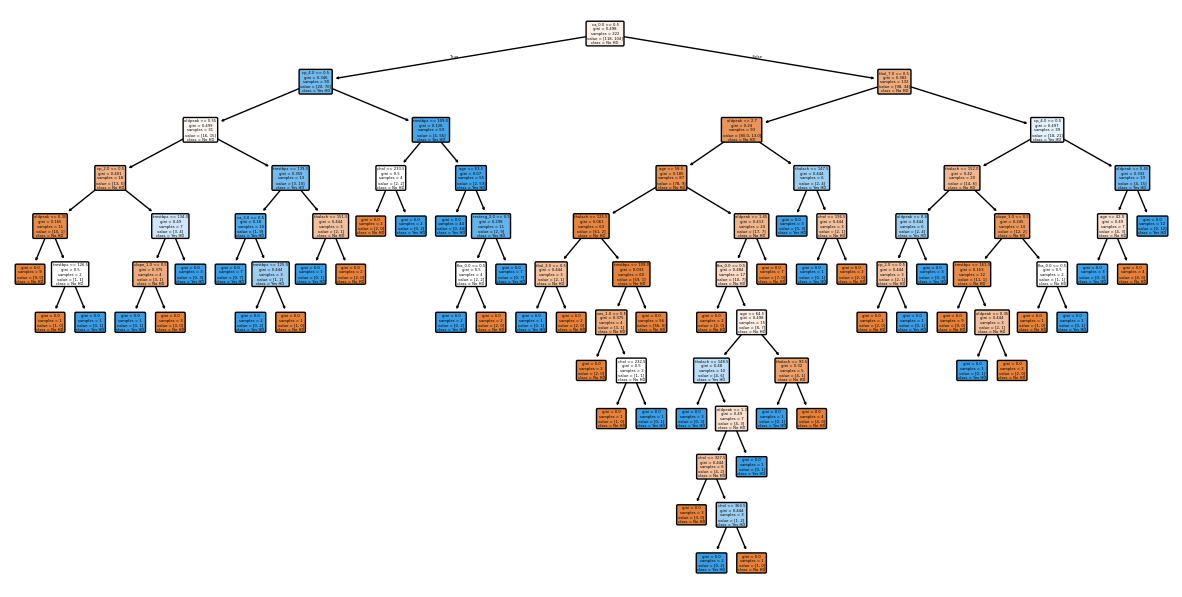

In [158]:
#print decision tree created
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig=plt.figure(figsize=(15,7.5))
plot_tree(clf_tree, filled=True,rounded=True,class_names=["No HD","Yes HD"], feature_names=X_train.columns)

We've created a preliminary decision tree (baseline) which is not optimized right now.

We'll cover how to optimize this in a bit

Check how it performs against test dataset now.
Confusion matrix created- Predicted value vs Actual value

[[31 11]
 [ 6 27]]


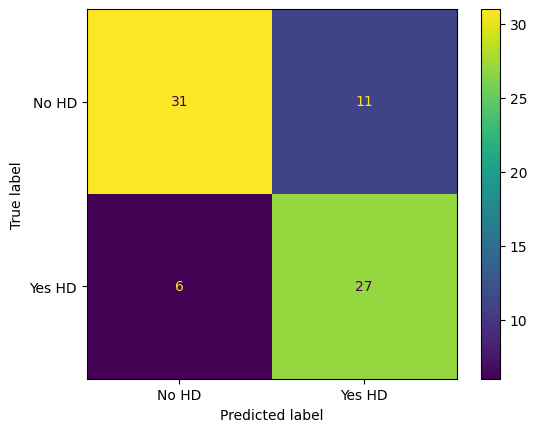

In [173]:
import sklearn.metrics as mt
from sklearn.metrics import ConfusionMatrixDisplay

print(mt.confusion_matrix(y_test, clf_tree.predict(X_test)))
ConfusionMatrixDisplay.from_estimator(clf_tree, X_test, y_test,display_labels=["No HD","Yes HD"])

17 test records are being incorrectly classified out of 75

Accuracy=58/75 = 0.773

TPR = 27/33 = 0.81

FPR = 11/37 = 0.297

Precision=27/38 = 0.71

In [176]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report
print("Accuracy score", accuracy_score(y_test, clf_tree.predict(X_test)))
print("recall score", recall_score(y_test, clf_tree.predict(X_test)))
print("precision score", precision_score(y_test, clf_tree.predict(X_test)))

Accuracy score 0.7733333333333333
recall score 0.8181818181818182
precision score 0.7105263157894737


Let's see if this tree is overfitted and if it can be optimized further.

Cost complexity pruning will be covered here

First get all possible list of alphas using which pruned trees can be built except for the last one where only root node is defined (not a tree) - We will do this on train dataset only, not on entire dataset or test dataset because we're trying to address overfitting issue here

In [178]:
clf_tree.cost_complexity_pruning_path(X_train,y_train) #to determine values of alpha

{'ccp_alphas': array([0.        , 0.00295295, 0.003861  , 0.00405405, 0.004095  ,
        0.00429358, 0.00514801, 0.00541298, 0.00578761, 0.00600601,
        0.00600601, 0.00600601, 0.00667591, 0.00675676, 0.00757375,
        0.00811505, 0.00868726, 0.00889851, 0.01038181, 0.0105777 ,
        0.01422475, 0.01604051, 0.01642461, 0.02103075, 0.03680006,
        0.03934523, 0.13046216]),
 'impurities': array([0.        , 0.00885886, 0.02430287, 0.03241098, 0.04060099,
        0.04918815, 0.06463216, 0.08628407, 0.10364689, 0.10965289,
        0.1216649 , 0.13367692, 0.14035282, 0.14710958, 0.15468333,
        0.17091343, 0.17960069, 0.18849919, 0.19888101, 0.2094587 ,
        0.2379082 , 0.25394872, 0.27037333, 0.29140408, 0.32820413,
        0.36754937, 0.49801153])}

In [181]:
path=clf_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
ccp_alphas=ccp_alphas[:-1] #exclude last alpha which will give just the root node without a tree
ccp_alphas

array([0.        , 0.00295295, 0.003861  , 0.00405405, 0.004095  ,
       0.00429358, 0.00514801, 0.00541298, 0.00578761, 0.00600601,
       0.00600601, 0.00600601, 0.00667591, 0.00675676, 0.00757375,
       0.00811505, 0.00868726, 0.00889851, 0.01038181, 0.0105777 ,
       0.01422475, 0.01604051, 0.01642461, 0.02103075, 0.03680006,
       0.03934523])

In [183]:
#now create a list of pruned decision trees created by using each alpha based on training data only
clfs=[]
for ccp_alpha in ccp_alphas:
  clf_dt=DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
  clf_dt.fit(X_train, y_train)
  clfs.append(clf_dt)
clfs

[DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.0029529529529529544),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.003861003861003862),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.004054054054054055),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.004095004095004095),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.004293579293579285),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.005148005148005148),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.005412976001211295),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.005787605787605791),
                        random_state=0),
 DecisionTreeClassifier(ccp_alpha=np.float64(0.006006006006

Then we'll check accuracy for train and test data wth these alpha values.

Plot them together

In [184]:
#fetch accuracy score for each pruned decision tree generated by all these values of alpha on train and test data
train_score=[clf.score(X_train, y_train) for clf in clfs]
test_score=[clf.score(X_test, y_test) for clf in clfs]

print(test_score)


[0.7466666666666667, 0.7466666666666667, 0.7466666666666667, 0.7466666666666667, 0.7466666666666667, 0.7733333333333333, 0.7733333333333333, 0.7733333333333333, 0.7733333333333333, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8133333333333334, 0.8133333333333334, 0.8133333333333334, 0.8266666666666667, 0.8266666666666667, 0.8533333333333334, 0.8533333333333334, 0.7866666666666666, 0.7066666666666667]


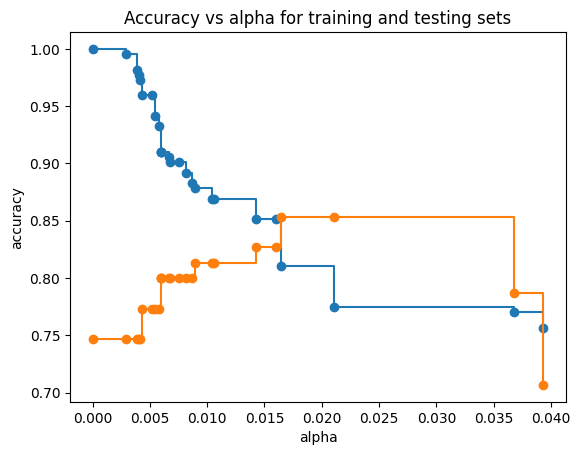

In [185]:
#plot alpha value vs accuracy score for both train and test datasets
fig, ax=plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_score, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_score, marker='o', label="test", drawstyle="steps-post")


As seen, with alpha=0 i.e. our preliminary tree that we built, train data has great accuracy but not for testing data.

Seems like around alpha=0.16 , both training and test data have good accuracy

Since we're using decision tree for classification, default method to build tree is by using Gini impurity. Gini is always between 0-1. Hence alpha values range is quite small.

If regression tree was built, alpha value could be large as we might be using sum of squared residuals to build the tree





Till now, we had divided data in one way and we're assuming that alpha value of 0.016 could be the optimum value.

Let's check further by subdividing data in multiple ways - get new train, test set and check if this alpha value is still optimum value for most cases i.e. k fold cross validation performed

In [218]:
#checking performance of alpha=0.16 with multiple combinations on train data
from sklearn.model_selection import cross_val_score
clf_tree1=DecisionTreeClassifier(random_state=42, ccp_alpha=0.016)

#cross_val_score_entire_dataset=cross_val_score(clf_tree, X_encoded, y_df, cv=20)
#print(cross_val_score_entire_dataset)

cross_val_scores_train_dataset=cross_val_score(clf_tree1, X_train, y_train, cv=10)
print(cross_val_scores_train_dataset)

[0.65217391 0.52173913 0.90909091 0.86363636 0.63636364 0.68181818
 0.77272727 0.77272727 0.72727273 0.81818182]



with cv=5 folds, we see one decision tree has high score and one with very low score

Experiment with other values of k fold-still difference is observed

<Axes: >

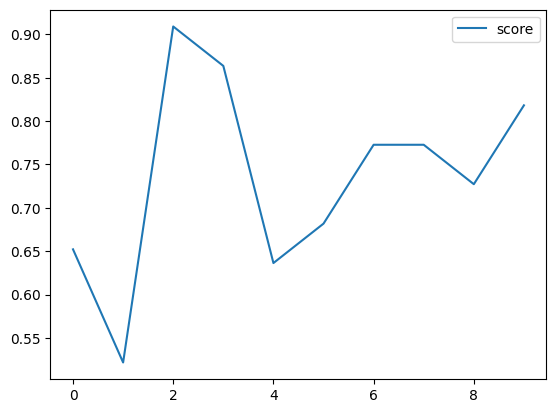

In [219]:
#create dataframe to store these score of cross validation against each k fold
cross_val_df=pd.DataFrame(cross_val_scores_train_dataset, columns=['score'])
cross_val_df.plot()
#plot the score for different subsets of train data


<Axes: xlabel='trees'>

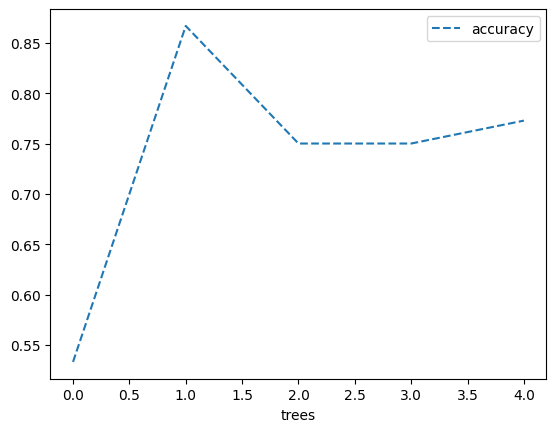

In [217]:
df=pd.DataFrame(data={"trees":range(5),"accuracy":cross_val_scores_train_dataset})
df.plot(x="trees",y="accuracy",linestyle='--')

Seems like alpha is sensitive to subset of data being used- model's accuracy varies in some cases

We'll use cross validation to find optimum value of alpha. i.e. for different subsets of data, find which alpha value is optimum (won't keep alpha fixed here obv)

We already have the list of alphas to generate pruned decision trees based on 70% of our entire data (intial train data)
We need to check for which other alpha values, if we apply cross validation - for most subset combo of data do we get maximum accuracy score.

In [225]:
#store list of alpha and the corresponding average accuracy score
#generated by this alpha with various k fold subsets of data
alpha_scores=[]
for alpha in ccp_alphas:
  clf_tree2=DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
  cv_scores=cross_val_score(clf_tree2, X_train, y_train, cv=5)
  #print(cv_scores)
  #print("alpha",alpha)

  #we want t take average of the scores generated by different folds for each alpha

  #print("average score",np.mean(cv_scores))
  alpha_scores.append((alpha,np.mean(cv_scores),np.std(cv_scores)))
alpha_scores

[(np.float64(0.0),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.0029529529529529544),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.003861003861003862),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.004054054054054055),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.004095004095004095),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.004293579293579285),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.005148005148005148),
  np.float64(0.6708080808080807),
  np.float64(0.09533791174863306)),
 (np.float64(0.005412976001211295),
  np.float64(0.6934343434343434),
  np.float64(0.0957792031153597)),
 (np.float64(0.005787605787605791),
  np.float64(0.7116161616161616),
  np.float64(0.09933253420607391)),
 (np.float64(0.006006006006006006),
  np.float64(0.711616161616

<Axes: >

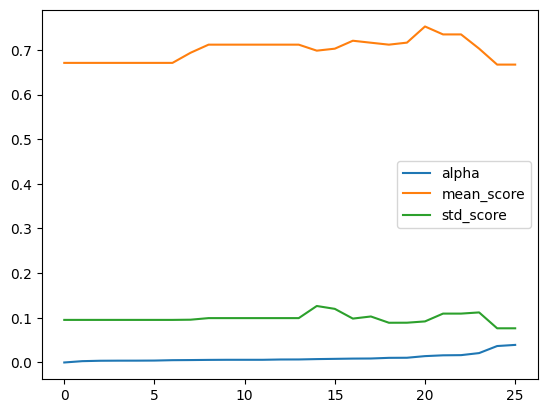

In [226]:
#plot alpha values against mean score generated using various subsets
alpha_Df=pd.DataFrame(alpha_scores, columns=["alpha","mean_score","std_score"])
alpha_Df.plot()

The above graph just takes default index as x axis and charts all numerical cols against y axis. Is difficult to interpret. Not even sure if it makes any sense. Plotting against default index doesn't make any sense/ add value

In below graph, we've added error factor - lines indicate range of error given by standard deviation value here. x axis is alpha here not just a default index.

<Axes: xlabel='alpha'>

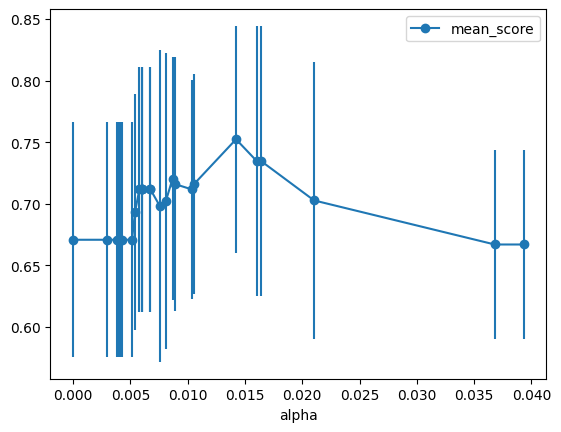

In [229]:
alpha_Df.plot(x="alpha",y="mean_score",yerr="std_score", marker='o')

Seems like around 0.014 might give better results than 0.016 that we got earlier.

Zoom in on this range of 0.014-0.015 and check exact alpha value at which max average score achieved

In [249]:
#zoom in on 0.014 -0.015 alpha ranges and get their mean score
alpha_scores #list of list -alpha, mean score, std dev
alpha_result=pd.DataFrame(alpha_scores,columns=["alpha","mean_score","std_dev"])
ideal_ccp_alpha_df=alpha_result.loc[(alpha_result["alpha"] >= 0.014) & (alpha_result["alpha"] < 0.015)]
ideal_ccp_alpha=float(ideal_ccp_alpha_df["alpha"] ) #returns series but we need a float value
type(ideal_ccp_alpha)

/tmp/ipython-input-1705417545.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ideal_ccp_alpha=float(ideal_ccp_alpha_df["alpha"] ) #returns series but we need a float value


float

Now pass this optimum value of alpha to build decision tree -our final optimized tree using
ideal_ccp_alpha

[Text(0.4583333333333333, 0.875, 'ca_0.0 <= 0.5\ngini = 0.498\nsamples = 222\nvalue = [118, 104]\nclass = No HD'),
 Text(0.25, 0.625, 'cp_4.0 <= 0.5\ngini = 0.346\nsamples = 90\nvalue = [20, 70]\nclass = Yes HD'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'oldpeak <= 0.55\ngini = 0.499\nsamples = 31\nvalue = [16, 15]\nclass = No HD'),
 Text(0.08333333333333333, 0.125, 'gini = 0.401\nsamples = 18\nvalue = [13, 5]\nclass = No HD'),
 Text(0.25, 0.125, 'gini = 0.355\nsamples = 13\nvalue = [3, 10]\nclass = Yes HD'),
 Text(0.3333333333333333, 0.375, 'gini = 0.126\nsamples = 59\nvalue = [4, 55]\nclass = Yes HD'),
 Text(0.6666666666666666, 0.625, 'thal_7.0 <= 0.5\ngini = 0.382\nsamples = 132\nvalue = [98, 34]\nclass = No HD'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'oldpeak <= 2.7\ngini = 0.24\nsamples = 93\nvalue = [80.0, 13.0]\nclass = No HD'),
 Text(0.4166666666666667, 0.125, 'gini = 0.185\nsamples = 87\nvalue = [78, 9]\nclass = No HD'),
 Text(

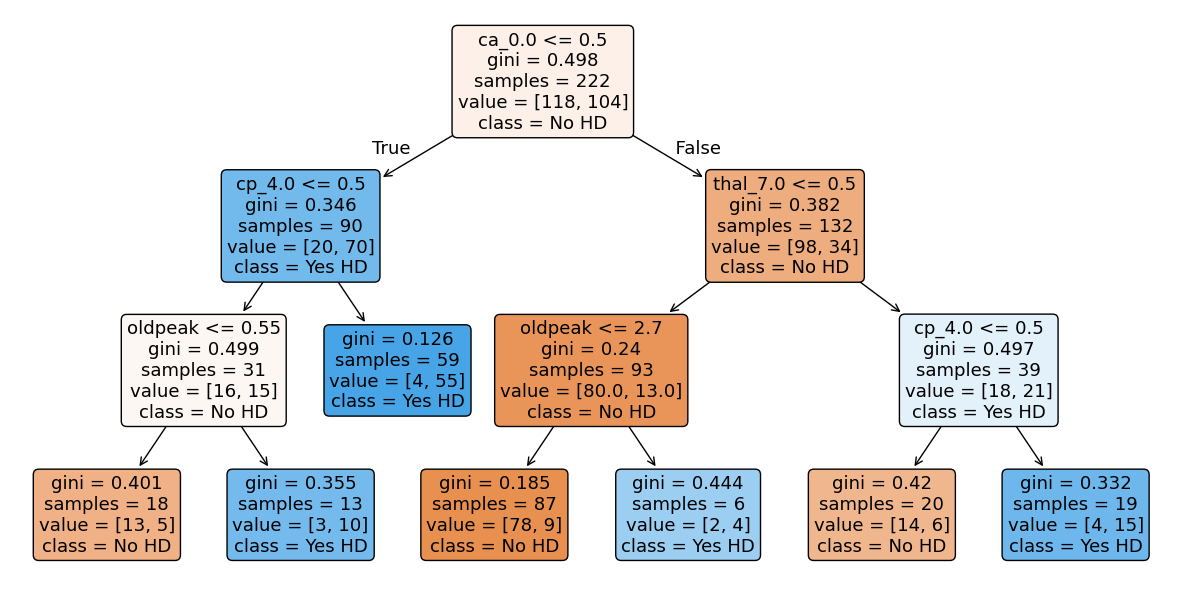

In [250]:
final_clf_tree=DecisionTreeClassifier(random_state=42, ccp_alpha=ideal_ccp_alpha)
final_clf_tree.fit(X_train, y_train)


fig=plt.figure(figsize=(15,7.5))
plot_tree(final_clf_tree, filled=True,rounded=True,class_names=["No HD","Yes HD"], feature_names=X_train.columns)

The color code above is to show concentration of class. Orange shades - darker it is, more number of records with No HD

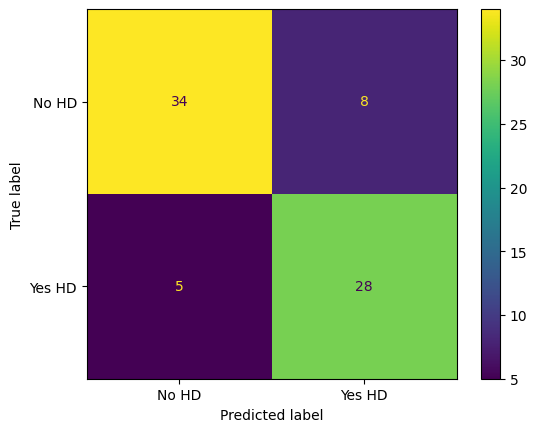

In [251]:
#confusion matrix with test data
ConfusionMatrixDisplay.from_estimator(final_clf_tree, X_test, y_test,display_labels=["No HD","Yes HD"])

In [254]:
print("Accuracy score", accuracy_score(y_test, final_clf_tree.predict(X_test)))
print("recall score", recall_score(y_test, final_clf_tree.predict(X_test)))
print("precision score", precision_score(y_test, final_clf_tree.predict(X_test)))

#there's little bit improvement with this test result compared to earlier.
#The point here is that this optimized tree will likely give decent results with different subsets
#earlier tree would have given less accuracy with different subset


Accuracy score 0.8266666666666667
recall score 0.8484848484848485
precision score 0.7777777777777778


Optimum alpha value can also be found by using - Grid search